# Discovering Physical Laws with Neurosymbolic AI
## Objectives

* Understand the limitations of "Black Box" Neural Networks in scientific contexts.
* Implement Symbolic Regression (SR) to discover analytical expressions from noisy data.
* Bridge the gap between machine learning output and physical constants (The "Neurosymbolic Bridge").


## 1. The Scenario: The "Digital Galileo"
Imagine you are observing a simple pendulum in a lab. You vary the length of the string ($L$) and measure the time it takes for one full oscillation ($T$). Your goal is to find the mathematical law that relates $L$ to $T$.
Data Generation: Run the following code to simulate your experimental data. We add Gaussian noise to simulate real-world measurement errors.

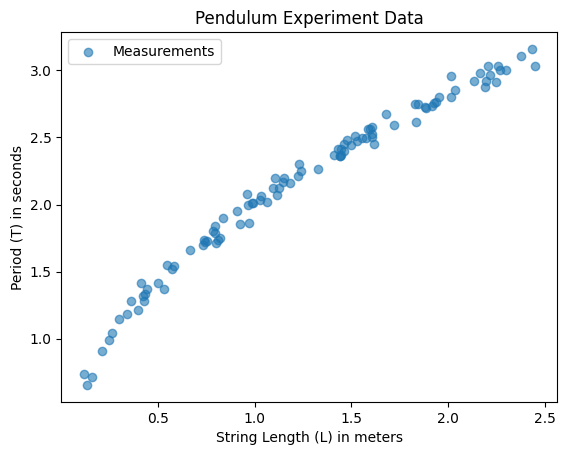

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Experimental Setup
g_true = 9.80665  # Earth gravity (m/s^2)
n_samples = 100
noise_intensity = 0.05 

# Independent variable: Length (m)
L = np.random.uniform(0.1, 2.5, n_samples)

# Dependent variable: Period (s) -> T = 2 * pi * sqrt(L/g)
T_clean = 2 * np.pi * np.sqrt(L / g_true)
T_noisy = T_clean + np.random.normal(0, noise_intensity, n_samples)

plt.scatter(L, T_noisy, alpha=0.6, label="Measurements")
plt.xlabel("String Length (L) in meters")
plt.ylabel("Period (T) in seconds")
plt.title("Pendulum Experiment Data")
plt.legend()
plt.show()

## 2. The Neural Baseline (Black Box)
Train a standard Multi-Layer Perceptron (MLP) to predict $T$ from $L$.
Task:
1. Train the model until the loss converges.
2. Observe the internal weights of the model.
3. Question: Can you find $g$ or $\pi$ inside these weights?

MLP Extrapolation for 10m: 11.69s
MLP Extrapolation for 50m: 54.16s


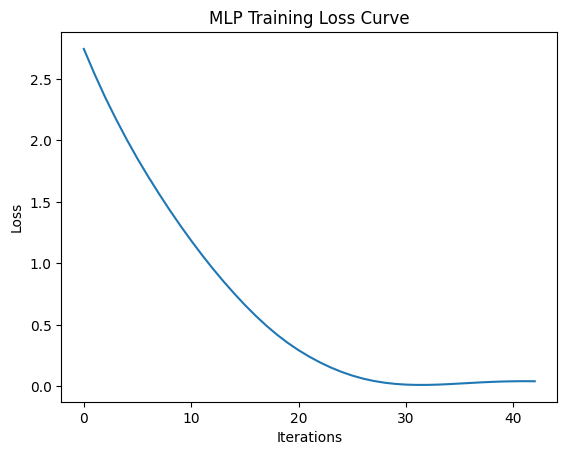

[array([[-5.79241144e-02,  1.07010126e-01,  9.06991628e-02,
         9.22783000e-02,  7.00746104e-02,  4.67936361e-02,
         4.95344894e-02,  1.53979033e-01, -7.53378060e-02,
         7.99254924e-02,  1.85222277e-01,  1.66206237e-01,
         1.47917273e-01, -1.45092928e-01,  5.84873575e-02,
         2.57811455e-02, -2.02812616e-01,  1.43266239e-01,
        -4.70510310e-02, -8.38616061e-02, -7.46990324e-02,
         4.76469276e-02, -1.18967921e-01, -1.53211599e-01,
        -6.28289814e-02, -6.22547096e-02,  1.15933728e-01,
         1.75232905e-01, -1.70841761e-01, -1.04108763e-01,
         2.63717249e-01, -2.91185571e-02, -1.62888505e-01,
         4.81218571e-02,  3.44824923e-02, -1.74600460e-01,
         2.48201788e-01,  8.69513830e-02, -1.32813297e-01,
         5.14661429e-02, -2.04404773e-01, -7.16080491e-02,
         1.10710868e-01,  2.59604967e-01, -4.30539259e-02,
         1.94906834e-01,  2.20337687e-01, -6.50607733e-02,
         2.18354514e-01, -7.84047671e-02, -8.10622248e-

In [2]:
from sklearn.neural_network import MLPRegressor

X = L.reshape(-1, 1)
y = T_noisy

mlp = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=5000)
mlp.fit(X, y)


# Test extrapolation: Predicting for a 10m and 50m pendulum
L_extrap = np.array([[10.0], [50.0]])
preds = mlp.predict(L_extrap)
print(f"MLP Extrapolation for 10m: {preds[0]:.2f}s")
print(f"MLP Extrapolation for 50m: {preds[1]:.2f}s")

plt.plot(mlp.loss_curve_) 
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

print(mlp.coefs_)

## 3. The Symbolic Discovery
Now we use PySR to search the space of mathematical expressions. This is the Symbolic part of the Neurosymbolic approach. It uses an evolutionary algorithm to find the simplest equation that fits the data.

Task: 
1. Run the regressor. 
2. Look at the output table. Identify the equation with the best score.

In [3]:
# from pysr import PySRRegressor

# model = PySRRegressor(
#     niterations=40,
#     binary_operators=["+", "*", "/", "^"],
#     unary_operators=["sqrt"],
#     elementwise_loss="loss(prediction, target) = (prediction - target)^2",
# )

# model.fit(X, y)
# print(model.equations_)

In [4]:
# [ Info: Started!

# Expressions evaluated per second: 4.350e+04
# Progress: 254 / 1240 total iterations (20.484%)
# ════════════════════════════════════════════════════════════════════════════════════════════════════
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# Complexity  Loss       Score      Equation
# 1           4.814e-01  0.000e+00  y = 2.0391
# 3           1.184e-02  1.853e+00  y = x₀ + 0.8813
# 4           2.273e-03  1.651e+00  y = sqrt(x₀ * 4.0051)
# 6           2.230e-03  9.557e-03  y = sqrt((x₀ / 0.25157) + 0.034124)
# 7           2.178e-03  2.341e-02  y = ((x₀ ^ 0.54907) + 0.08605) / 0.54616
# 8           2.175e-03  1.613e-03  y = (sqrt(x₀ ^ 1.0505) + 0.050734) * 1.8994
# 10          2.154e-03  4.888e-03  y = x₀ + sqrt((x₀ / (x₀ ^ x₀)) ^ 0.52842)
# 12          2.147e-03  1.675e-03  y = (x₀ + sqrt((x₀ / (x₀ ^ x₀)) ^ 0.51745)) * 0.99821
# 14          2.147e-03  1.192e-07  y = (sqrt(((x₀ / (x₀ ^ x₀)) ^ 0.58914) ^ 0.87822) + x₀) * ...
#                                       0.99821
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════════════════════════
# Press 'q' and then <enter> to stop execution early.

# Expressions evaluated per second: 5.540e+04
# Progress: 722 / 1240 total iterations (58.226%)
# ════════════════════════════════════════════════════════════════════════════════════════════════════
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# Complexity  Loss       Score      Equation
# 1           4.814e-01  0.000e+00  y = 2.0391
# 3           1.184e-02  1.853e+00  y = x₀ + 0.8813
# 4           2.273e-03  1.651e+00  y = sqrt(x₀) * 2.0013
# 6           2.229e-03  9.702e-03  y = sqrt(x₀ + 0.007707) * 1.9947
# 7           2.159e-03  3.227e-02  y = ((x₀ + 0.029589) ^ 0.51767) * 1.9637
# 9           2.154e-03  1.123e-03  y = x₀ + ((x₀ / (x₀ ^ x₀)) ^ 0.26424)
# 11          2.146e-03  1.785e-03  y = (x₀ * 0.997) + ((x₀ / (x₀ ^ x₀)) ^ 0.25868)
# 13          2.146e-03  2.903e-05  y = (x₀ + ((x₀ / (x₀ ^ (x₀ + 0.0060215))) ^ 0.26025)) * 0....
#                                       99856
# 15          2.144e-03  3.350e-04  y = ((x₀ * 1.0034) + ((x₀ / ((x₀ ^ x₀) + -0.040512)) ^ 0.2...
#                                       5455)) + -0.017073
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════════════════════════
# Press 'q' and then <enter> to stop execution early.

# Expressions evaluated per second: 5.710e+04
# Progress: 1043 / 1240 total iterations (84.113%)
# ════════════════════════════════════════════════════════════════════════════════════════════════════
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# Complexity  Loss       Score      Equation
# 1           4.814e-01  0.000e+00  y = 2.0391
# 3           1.184e-02  1.853e+00  y = x₀ + 0.8813
# 4           2.273e-03  1.651e+00  y = sqrt(x₀) * 2.0013
# 5           2.268e-03  2.118e-03  y = (x₀ ^ 0.49808) * 2.0026
# 6           2.229e-03  1.729e-02  y = sqrt(x₀ + 0.0076637) * 1.9947
# 7           2.159e-03  3.227e-02  y = ((x₀ + 0.029589) ^ 0.51767) * 1.9637
# 9           2.154e-03  1.123e-03  y = x₀ + ((x₀ / (x₀ ^ x₀)) ^ 0.26424)
# 11          2.146e-03  1.785e-03  y = (x₀ * 0.997) + ((x₀ / (x₀ ^ x₀)) ^ 0.25868)
# 13          2.146e-03  4.959e-05  y = x₀ + (((x₀ / (x₀ ^ (x₀ + 0.012301))) ^ 0.26152) * 0.99...
#                                       708)
# 15          2.144e-03  3.144e-04  y = ((x₀ * 1.0034) + ((x₀ / ((x₀ ^ x₀) + -0.040512)) ^ 0.2...
#                                       5455)) + -0.017073
# 17          2.107e-03  8.843e-03  y = ((x₀ + (0.040607 / ((x₀ ^ ((x₀ * x₀) * x₀)) ^ x₀))) ^ ...
#                                       0.53313) * 1.9583
# 20          2.106e-03  1.820e-04  y = ((x₀ + (0.040607 / (((x₀ ^ (x₀ * (x₀ * x₀))) ^ x₀) ^ s...
#                                       qrt(x₀)))) ^ 0.53313) * 1.9583
# 23          2.106e-03  1.689e-05  y = ((x₀ + (0.040607 / (((x₀ ^ ((x₀ * x₀) * x₀)) ^ x₀) ^ (...
#                                       sqrt(x₀) ^ sqrt(x₀))))) ^ 0.53313) * 1.9583
# 28          2.106e-03  1.226e-05  y = ((x₀ + (0.040813 / (((x₀ ^ ((x₀ * x₀) * x₀)) ^ x₀) ^ s...
#                                       qrt(sqrt(x₀ ^ sqrt(x₀ * (x₀ * x₀))))))) ^ 0.53345) * 1.957...
#                                       9
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════════════════════════
# Press 'q' and then <enter> to stop execution early.
# [ Info: Final population:
# [ Info: Results saved to:
# ───────────────────────────────────────────────────────────────────────────────────────────────────
# Complexity  Loss       Score      Equation
# 1           4.814e-01  0.000e+00  y = 2.0391
# 3           1.184e-02  1.853e+00  y = x₀ + 0.8813
# 4           2.273e-03  1.651e+00  y = sqrt(x₀) * 2.0013
# 5           2.268e-03  2.118e-03  y = (x₀ ^ 0.49808) * 2.0026
# 6           2.229e-03  1.729e-02  y = sqrt(x₀ + 0.0076785) * 1.9947
# 7           2.159e-03  3.227e-02  y = ((x₀ + 0.029589) ^ 0.51767) * 1.9637
# 9           2.154e-03  1.123e-03  y = x₀ + ((x₀ / (x₀ ^ x₀)) ^ 0.26424)
# 11          2.146e-03  1.792e-03  y = ((x₀ / (x₀ ^ x₀)) ^ 0.25905) + (x₀ * 0.99717)
# 13          2.146e-03  4.274e-05  y = x₀ + (((x₀ / (x₀ ^ (x₀ + 0.012301))) ^ 0.26152) * 0.99...
#                                       708)
# 15          2.109e-03  8.736e-03  y = (((0.040607 / (x₀ ^ ((x₀ * x₀) ^ 1.8534))) + x₀) ^ 0.5...
#                                       3313) * 1.9583
# 17          2.106e-03  6.723e-04  y = ((x₀ + (0.040607 / (x₀ ^ ((x₀ * x₀) ^ (1.5541 ^ 1.9583...
#                                       ))))) ^ 0.53313) * 1.9583
# 19          2.103e-03  7.293e-04  y = (1.996 * (((0.048384 / (((x₀ ^ x₀) ^ x₀) ^ (x₀ * x₀)))...
#                                        + x₀) ^ 0.52758)) + -0.043884
# 22          2.102e-03  1.254e-04  y = ((((0.048384 / (((x₀ ^ x₀) ^ x₀) ^ ((x₀ * x₀) * sqrt(x...
#                                       ₀)))) + x₀) ^ 0.52758) * 1.996) + -0.043884
# 25          2.101e-03  1.050e-04  y = -0.035131 + (1.9865 * ((x₀ + (0.048556 / (((x₀ ^ x₀) ^...
#                                        (x₀ * (x₀ ^ (x₀ ^ -0.79203)))) ^ (x₀ ^ x₀)))) ^ 0.53006))
# ───────────────────────────────────────────────────────────────────────────────────────────────────
#     complexity      loss                                           equation  \
# 0            1  0.481447                                          2.0391233   
# 1            3  0.011842                                     x0 + 0.8813019   
# 2            4  0.002273                               sqrt(x0) * 2.0012674   
# 3            5  0.002268                       (x0 ^ 0.49808237) * 2.002575   
# 4            6  0.002229                sqrt(x0 + 0.0076784715) * 1.9946764   
# 5            7  0.002159      ((x0 + 0.029589336) ^ 0.51766795) * 1.9637158   
# 6            9  0.002154               x0 + ((x0 / (x0 ^ x0)) ^ 0.26423538)   
# 7           11  0.002146  ((x0 / (x0 ^ x0)) ^ 0.25905433) + (x0 * 0.9971...   
# 8           13  0.002146  x0 + (((x0 / (x0 ^ (x0 + 0.01230085))) ^ 0.261...   
# 9           15  0.002109  (((0.04060702 / (x0 ^ ((x0 * x0) ^ 1.8534195))...   
# 10          17  0.002106  ((x0 + (0.04060702 / (x0 ^ ((x0 * x0) ^ (1.554...   
# 11          19  0.002103  (1.9960434 * (((0.04838401 / (((x0 ^ x0) ^ x0)...   
# 12          22  0.002102  ((((0.04838401 / (((x0 ^ x0) ^ x0) ^ ((x0 * x0...   
# 13          25  0.002101  -0.035131082 + (1.9865171 * ((x0 + (0.04855615...   

#        score                                       sympy_format  \
# 0   0.000000                                   2.03912330000000   
# 1   1.852585                                     x0 + 0.8813019   
# 2   1.650514                                 2.0012674*sqrt(x0)   
# 3   0.002118                            x0**0.49808237*2.002575   
# 4   0.017288                  1.9946764*sqrt(x0 + 0.0076784715)   
# 5   0.032266           (x0 + 0.029589336)**0.51766795*1.9637158   
# 6   0.001123                     x0 + (x0/(x0**x0))**0.26423538   
# 7   0.001792          x0*0.99716944 + (x0/(x0**x0))**0.25905433   
# 8   0.000043  x0 + (x0/(x0**(x0 + 0.01230085)))**0.2615172*0...   
# 9   0.008736  (x0 + 0.04060702/(x0**((x0*x0)**1.8534195)))**...   
# 10  0.000672  (x0 + 0.04060702/(x0**((x0*x0)**(1.5541484**1....   
# 11  0.000729  1.9960434*(x0 + 0.04838401/(((x0**x0)**x0)**(x...   
# 12  0.000125  1.9960434*(x0 + 0.04838401/((x0**x0)**x0)**(x0...   
# 13  0.000105  1.9865171*(x0 + 0.048556153/(((x0**x0)**(x0*x0...   

#                                         lambda_format  
# 0                   PySRFunction(X=>2.03912330000000)  
# 1                     PySRFunction(X=>x0 + 0.8813019)  
# 2                 PySRFunction(X=>2.0012674*sqrt(x0))  
# 3            PySRFunction(X=>x0**0.49808237*2.002575)  
# 4   PySRFunction(X=>1.9946764*sqrt(x0 + 0.00767847...  
# 5   PySRFunction(X=>(x0 + 0.029589336)**0.51766795...  
# 6     PySRFunction(X=>x0 + (x0/(x0**x0))**0.26423538)  
# 7   PySRFunction(X=>x0*0.99716944 + (x0/(x0**x0))*...  
# 8   PySRFunction(X=>x0 + (x0/(x0**(x0 + 0.01230085...  
# 9   PySRFunction(X=>(x0 + 0.04060702/(x0**((x0*x0)...  
# 10  PySRFunction(X=>(x0 + 0.04060702/(x0**((x0*x0)...  
# 11  PySRFunction(X=>1.9960434*(x0 + 0.04838401/(((...  
# 12  PySRFunction(X=>1.9960434*(x0 + 0.04838401/((x...  
# 13  PySRFunction(X=>1.9865171*(x0 + 0.048556153/((...  
#   - outputs/20260111_192742_87S5B1/hall_of_fame.csv


The output is: $T = 2.0012674 \cdot \sqrt{L}$

In [5]:
print(2*np.pi/np.sqrt(g_true))

2.0064092925890407



## 4. The Neurosymbolic Bridge
Once the AI provides an equation like $T = 2.01 \cdot \sqrt{L}$:
1. Identify the Form: Match the AI output to the theoretical formula:
$$T = \frac{2\pi}{\sqrt{g}} \sqrt{L}$$
2. Extract the Constant: If your discovered constant is $C$, then $C = \frac{2\pi}{\sqrt{g}}$. Calculate the value of $g$ (Gravity).
3. Extrapolation Test: Use your discovered formula to predict the period for $L = 100m$. Compare this to the Neural Network's prediction. Which one follows the laws of physics?

# Lab Report Requirements
1. Visuals: Show the scatter plot of the data and the curve-fit of your discovered equation.
2. The Equation: Provide the LaTeX version of the best equation found by PySR.
3. Physics Discovery: Show your step-by-step calculation for $g$. How close did the AI get to $9.81 m/s^2$?
4. Discussion: Explain why the Neural Network failed at extrapolation ($L=50m$).Why is a symbolic model more useful for an engineer than a black-box model?